## Expert Knowledge Worker

### A question answering agent that is an expert knowledge worker
### To be used by employees of Insurellm, an Insurance Tech company
### The agent needs to be accurate and the solution should be low cost.

This project will use RAG (Retrieval Augmented Generation) to ensure our question/answering assistant has high accuracy.

## TODAY:

- Part A: We will divide our documents into CHUNKS
- Part B: We will encode our CHUNKS into VECTORS and put in Chroma
- Part C: We will visualize our vectors

In [1]:
import os
import glob
import tiktoken
import numpy as np
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.manifold import TSNE
import plotly.graph_objects as go



/Users/tarkshya/Work/LLM Engineering/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/15/c_1pjyqd41g1973nb1t0wpd80000gn/T/ipykernel_35715/3836212013.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, TextLoader


- Langchain chroma for using OPENAI classes
- chroma for DATABASE
- One for huggingface Classes
 - Set of Document Loaders which are its tools for loading documents which are in the Langchain community which is a bit like the community Contributions where people have added in some open src contributions.
- text_splitters which is a particular, a part of Langchain that's responsible for taking documents and turning them into chunks.


In [2]:
MODEL = "gpt-4o-nano"
db_name = "vector_db"
load_dotenv(override=True)
openai_api_key = os.getenv("OPENAI_API_KEY")

In [3]:
# how many characters in all the documents
knowledge_base_path = "knowledge-base/**/*.md"
files = glob.glob(knowledge_base_path,recursive=True)
print(f"Found {len(files)} files in knowledge_base")

entire_knowledge_base = ""
for file_path in files:
    with open(file_path, "r") as f:
        entire_knowledge_base += f.read()
        entire_knowledge_base+="\n\n"

print(f"Total characters in knowledge_base: {len(entire_knowledge_base)}")

Found 76 files in knowledge_base
Total characters in knowledge_base: 304434


In [4]:
# How many Tokens in all the documents
# for this we will use TikToken
encoding = tiktoken.encoding_for_model(MODEL)
tokens = encoding.encode(entire_knowledge_base)
token_count = len(tokens)
print(f"Total tokens for {MODEL}:{token_count}")

Total tokens for gpt-4o-nano:63555


In [5]:
# Loading in Everything in the knowledgeBase using LangChain's Loaders

# Check NoteBook Notes for doubt clearance in notion
folders = glob.glob("knowledge-base/*")

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder,glob = "**/*.md",loader_cls=TextLoader,loader_kwargs={"encoding":"utf-8"})
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

print(f"Loaded {len(documents)} documents")

Loaded 76 documents


In [6]:
print(documents[25].metadata["doc_type"])

contracts


In [7]:
# Divide into chunks using the RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")
print(f"First chunk:\n\n{chunks[0]}")

Divided into 413 chunks
First chunk:

page_content='# Product Summary

# Rellm: AI-Powered Enterprise Reinsurance Solution

## Summary

Rellm is an innovative enterprise reinsurance product developed by Insurellm, designed to transform the way reinsurance companies operate. Harnessing the power of artificial intelligence, Rellm offers an advanced platform that redefines risk management, enhances decision-making processes, and optimizes operational efficiencies within the reinsurance industry. With seamless integrations and robust analytics, Rellm enables insurers to proactively manage their portfolios and respond to market dynamics with agility.

## Features

### AI-Driven Analytics
Rellm utilizes cutting-edge AI algorithms to provide predictive insights into risk exposures, enabling users to forecast trends and make informed decisions. Its real-time data analysis empowers reinsurance professionals with actionable intelligence.' metadata={'source': 'knowledge-base/products/Rellm.md', '

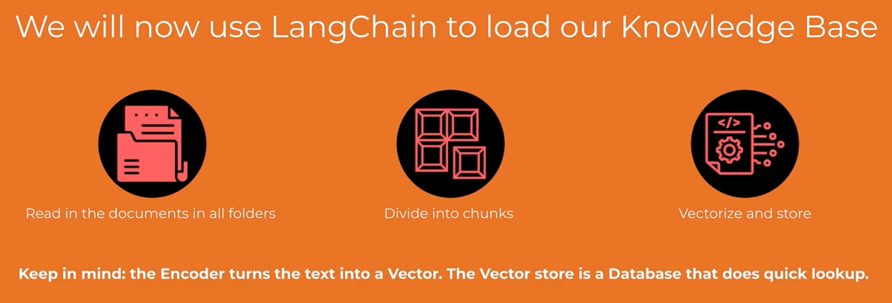

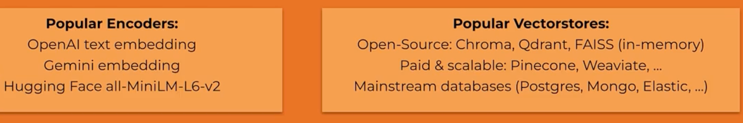

In [8]:
# Picking an embedding Model

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

if os.path.exists("db_name"):
    Chroma(persist_directory=f"db_name",embedding_function=embeddings).delete_collection()
vectorstore = Chroma.from_documents(documents = chunks, embedding = embeddings, persist_directory=db_name)

print(f"vectorstore created with {vectorstore._collection.count()} documents")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7548.59it/s]


vectorstore created with 2065 documents


In [9]:
# Let's investigate the vectors
# Check Notebook notes for doubt clearance in notion
collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1,include = ["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)

print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

There are 2,065 vectors with 384 dimensions in the vector store


### Part C: Visualize!

In [10]:
# Prework # This code isn't that important so no need to worry.

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['doc_type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

In [13]:
# We humans find it easier to visalize things in 2D!
# Reduce the dimensionality of the vectors to 2D using t-SNE
# (t-distributed stochastic neighbor embedding)

tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [12]:
# Let's try 3D!

tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()